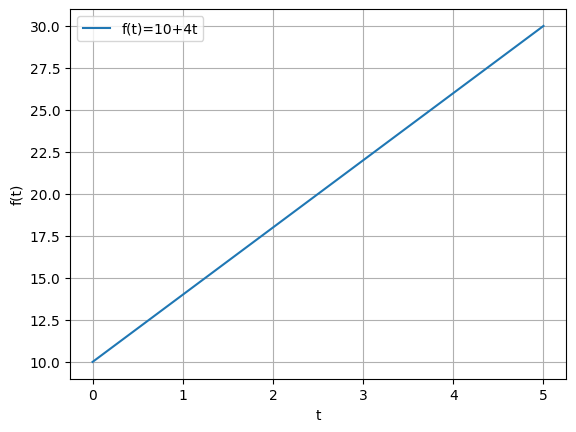

5 -> 90.000
20 -> 97.500
100 -> 99.500
Exact integral: 100
Trapezoid bilan tekshirish
5 --> 100.000
20 --> 100.000
100 --> 100.000
Riemann Sum xatoliklari
5 -> qiymat: 90.000, xatolik: 10.000
20 -> qiymat: 97.500, xatolik: 2.500
100 -> qiymat: 99.500, xatolik: 0.500


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1 - Grafik chizish
def f(t):
    return 10 + 4*t
numbers = np.linspace(0, 5, 20)

plt.plot(numbers, f(numbers), label='f(t)=10+4t')
plt.legend()
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid()
plt.show()


# 2 - Riemann Sum bilan suv miqdorini hisoblash
def left_riemann(f, a, b, n):
    dx = (b - a) / n
    xs = np.linspace(a, b, n, endpoint=False)
    return np.sum(f(xs) * dx)

for i in [5, 20, 100]:
    print(f"{i} -> {left_riemann(f, 0, 5, i):.3f}")

# 3 - Aniq integral bilan haqiqiy qiymatni topish
x = sp.Symbol('x')
fu = 10 + 4*x

exact = sp.integrate(fu, (x, 0, 5))
print(f"Exact integral: {exact}")


# 4 - Trapezoid bilan tekshirish
print("Trapezoid bilan tekshirish")
def test_with_trapezoid(f, a, b, n):
    xs = np.linspace(a, b, n + 1)
    ys = f(xs)
    return np.trapezoid(ys, xs)

for i in [5, 20, 100]:
    print(f"{i} --> {test_with_trapezoid(f, 0, 5, i):.3f}")


# 5 - Xatolikni hisoblash
print("Riemann Sum xatoliklari")
for i in [5, 20, 100]:
    result = left_riemann(f, 0, 5, i)
    error = abs(float(exact) - result)
    print(f"{i} -> qiymat: {result:.3f}, xatolik: {error:.3f}")
# bunda n oshgani sari xatolik kamayib borayapti, to'rtburchaklar soni ko'paygan
# har bir to'rtburchakning eni kichrayadi va grafik yuzasiga yaxshiroq joylashadi.


In [29]:
import numpy as np
import sympy as sp

def P(t):
    return 5 + 2*t


# 1. Riemann Sum
def left_riemann(f, a, b, n):
    dx = (b - a) / n
    xs = np.linspace(a, b, n, endpoint=False)
    return np.sum(f(xs) * dx)


print("Riemann Sum:")
for n in [6, 60]:
    result = left_riemann(P, 0, 6, n)
    print(f"n = {n}: {result:.3f} kWh")


# 2. Aniq integral
t = sp.Symbol('t')

P_symbolic = 5 + 2*t

exact = sp.integrate(P_symbolic, (t, 0, 6))

print("\nAniq integral:")
print(f"Integral = {exact} kWh")


# 3. np.trapezoid() bilan hisoblash
def trapezoid(f, a, b, n):
    xs = np.linspace(a, b, n + 1)
    ys = f(xs)
    return np.trapezoid(ys, xs)


print("\nTrapezoid:")
for n in [6, 60]:
    result = trapezoid(P, 0, 6, n)
    print(f"n = {n}: {result:.3f} kWh")


# 4. Xatoliklarni hisoblash
exact_float = float(exact)

print("\nRiemann Sum xatoliklari:")
for n in [6, 60]:
    result = left_riemann(P, 0, 6, n)
    error = abs(exact_float - result)
    print(f"n = {n}: xatolik = {error:.3f} kWh")


print("\nTrapezoid xatoliklari:")
for n in [6, 60]:
    result = trapezoid(P, 0, 6, n)
    error = abs(exact_float - result)
    print(f"n = {n}: xatolik = {error:.3f} kWh")


Riemann Sum:
n = 6: 60.000 kWh
n = 60: 65.400 kWh

Aniq integral:
Integral = 66 kWh

Trapezoid:
n = 6: 66.000 kWh
n = 60: 66.000 kWh

Riemann Sum xatoliklari:
n = 6: xatolik = 6.000 kWh
n = 60: xatolik = 0.600 kWh

Trapezoid xatoliklari:
n = 6: xatolik = 0.000 kWh
n = 60: xatolik = 0.000 kWh


AUC = 0.81675


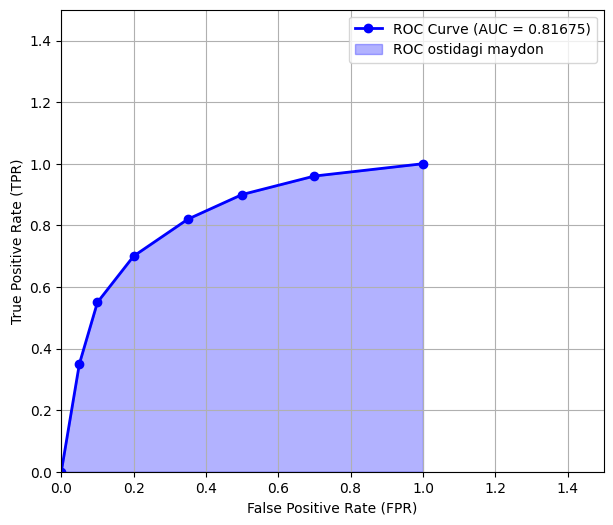

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fpr = np.array([0, .05, .1, .2, .35, .5, .7, 1])
tpr = np.array([0, .35, .55, .7, .82, .9, .96, 1])

# AUC hisoblash
auc = np.trapezoid(tpr, fpr)

print(f"AUC = {auc:.5f}")

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    marker='o',
    color='blue',
    linewidth=2,
    label=f'ROC Curve (AUC = {auc:.5f})'
)

plt.fill_between(
    fpr,
    tpr,
    alpha=0.3,
    color='blue',
    label='ROC ostidagi maydon'
)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.xlim(0, 1.5)
plt.ylim(0, 1.5)
plt.grid()
plt.legend()

plt.show()
# bizda 0.81675 chiqdi, bu bizni modelimiz yaxshi ishlayotganini bildiradi.
# 1 ga yaqinlashgani sari model yaxshi ishlayotgan bo'ladi, yani 81 % aniqlikda ishlayapti.
# bu yuqori natija, buni ozgina pastga tushurish kerak manimcha, chunki ustozimiz aytgandila
# max = 78 bo'lishi kerak deb. juda aniq ishlasa ham bo'maykan.